In [1]:
import numpy as np

# 定义给定的向量和矩阵
a = np.array([2, -1, 3])
b = np.array([1, 4, -2])

A = np.array([
    [1, 0, 2],
    [-1, 3, 1]
])

B = np.array([
    [2, 1],
    [0, -1],
    [3, 2]
])

# 1. 计算向量点积 a·b
# 也可使用 a @ b 或 (a * b).sum()
dot_prod = np.dot(a, b)
print("1. 向量点积 a·b =", dot_prod)

# 2. 计算矩阵乘法 A x B 及其结果矩阵的形状
mat_mul = np.dot(A, B) # 也可使用 A @ B
print("\n2. 矩阵乘法 A x B = \n", mat_mul)
print("   结果矩阵的形状: ", mat_mul.shape)

# 3. 计算向量 a 的 Frobenius 范数 (对于向量即 L2 范数)
frob_norm = np.linalg.norm(a)
print("\n3. 向量 a 的 Frobenius 范数 = {:.4f}".format(frob_norm))

1. 向量点积 a·b = -8

2. 矩阵乘法 A x B = 
 [[ 8  5]
 [ 1 -2]]
   结果矩阵的形状:  (2, 2)

3. 向量 a 的 Frobenius 范数 = 3.7417


In [2]:
import numpy as np

# 1. 创建一个形状为 3 × 4 的随机矩阵 X，元素服从标准正态分布
X = np.random.randn(3, 4)
print("矩阵 X:\n", X)

# 2. 创建一个形状为 4 × 2 的全 1 矩阵 Y
Y = np.ones((4, 2))
print("\n矩阵 Y:\n", Y)

# 3. 计算矩阵乘法 Z = X × Y
Z = np.dot(X, Y)  # 或者使用 Z = X @ Y
print("\n矩阵 Z (X × Y):\n", Z)

# 4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素
# 注意：Python 索引从 0 开始。
element = Z[0, 1]
row_2 = Z[1, :]
print(f"\nZ 第一行第二列交叉处的元素: {element}")
print(f"Z 第 2 行所有元素: {row_2}")

# 5. 计算 Z 的 Frobenius 范数
frobenius_norm = np.linalg.norm(Z, ord='fro')
print(f"\nZ 的 Frobenius 范数: {frobenius_norm}")

矩阵 X:
 [[ 0.17450741  0.0221971  -0.49862156 -0.26624007]
 [ 0.10139277  0.22475108  1.14533227 -0.14607857]
 [ 0.98080569  0.72825993  0.27771561  0.48555421]]

矩阵 Y:
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

矩阵 Z (X × Y):
 [[-0.56815712 -0.56815712]
 [ 1.32539754  1.32539754]
 [ 2.47233544  2.47233544]]

Z 第一行第二列交叉处的元素: -0.5681571193688629
Z 第 2 行所有元素: [1.32539754 1.32539754]

Z 的 Frobenius 范数: 4.047696555406833


### 3.1 理论计算题

**已知条件：**
* 患病概率：$P(D) = 0.1\% = 0.001$
* 未患病概率：$P(\neg D) = 1 - 0.001 = 0.999$
* 患病情况下检测为阳性的概率（灵敏度）：$P(+|D) = 99\% = 0.99$
* 未患病情况下检测为阳性的概率（假阳性）：$P(+|\neg D) = 2\% = 0.02$

**求解目标：** 检测为阳性时，真正患病的概率 $P(D|+)$

根据**贝叶斯公式**，我们有：
$$ P(D|+) = \frac{P(+|D)P(D)}{P(+)} = \frac{P(+|D)P(D)}{P(+|D)P(D) + P(+|\neg D)P(\neg D)} $$

In [ ]:
# 1. 定义已知概率
P_D = 0.001           # 患病率 P(D)
P_not_D = 1 - P_D     # 未患病率 P(~D)

P_pos_given_D = 0.99      # 患病且检测为阳性的概率 P(+|D)
P_pos_given_not_D = 0.02  # 未患病且检测为阳性的概率 P(+|~D) (假阳性)

# 2. 根据全概率公式计算检测结果呈阳性的总概率 P(+)
P_pos = P_pos_given_D * P_D + P_pos_given_not_D * P_not_D
print(f"检测呈阳性的总概率 P(+): {P_pos:.5f}")

# 3. 根据贝叶斯公式计算 P(D|+)
P_D_given_pos = (P_pos_given_D * P_D) / P_pos

print(f"\n结果: 如果检测结果为阳性，该人真正患病的概率为 {P_D_given_pos:.4%} ({P_D_given_pos:.4f})")

检测呈阳性的总概率 P(+): 0.02097

结果: 如果检测结果为阳性，该人真正患病的概率为 4.7210% (0.0472)


### 用 Python 模拟中心极限定理

根据中心极限定理，样本均值的分布会随着样本量 $n$ 的增大趋近于正态分布。
均匀分布 $U(0,1)$ 的理论均值 $\mu = 0.5$ ，方差 $\sigma^2 = \frac{1}{12}$。
样本均值的理论方差为 $\sigma_{\bar{X}}^2 = \frac{\sigma^2}{n} = \frac{1}{12n}$。

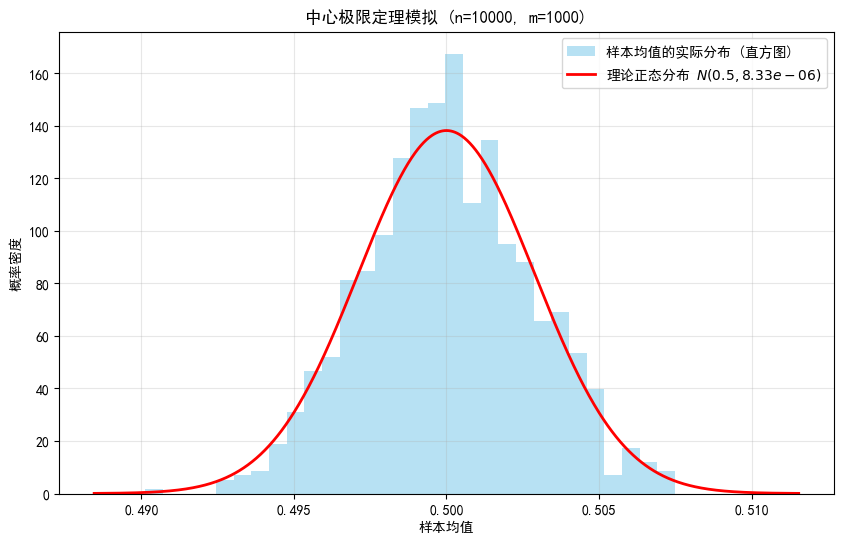

----------------------------------------
理论方差: 0.00000833
实际方差: 0.00000755
绝对误差: 0.00000079
----------------------------------------


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 设置参数并生成均匀分布样本
n = 10000  # 每次包含 n 个随机变量
m = 1000   # 重复 m 次

# 生成 m x n 的矩阵，所有元素服从 U(0, 1)
samples = np.random.uniform(0, 1, size=(m, n))

# 计算每次取样（每行）这 n 个变量的均值
means = np.mean(samples, axis=1)

# 2. 准备绘图与理论概率密度函数 (PDF)
# U(0,1) 的理论均值和方差
mu_unif = 0.5
var_unif = 1 / 12

# 根据中心极限定理，样本均值的理论均值和方差
mu_theoretical = mu_unif
var_theoretical = var_unif / n
std_theoretical = np.sqrt(var_theoretical)

plt.figure(figsize=(10, 6))

# 绘制这 1000 个均值的直方图 (density=True 归一化为概率密度)
plt.hist(means, bins=30, density=True, alpha=0.6, color='skyblue', label='样本均值的实际分布 (直方图)')

# 绘制理论上的正态分布概率密度曲线
x = np.linspace(mu_theoretical - 4 * std_theoretical, mu_theoretical + 4 * std_theoretical, 1000)
y = norm.pdf(x, mu_theoretical, std_theoretical)
plt.plot(x, y, 'r-', lw=2, label=f'理论正态分布 $N({mu_theoretical}, {var_theoretical:.2e})$')

plt.title(f'中心极限定理模拟 (n={n}, m={m})')
plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. 计算这 1000 个均值的实际方差
actual_variance = np.var(means, ddof=1) # 样本方差 (ddof=1)
print("-" * 40)
print(f"理论方差: {var_theoretical:.8f}")
print(f"实际方差: {actual_variance:.8f}")
print(f"绝对误差: {abs(var_theoretical - actual_variance):.8f}")
print("-" * 40)

### 4.1 理论计算题

给定函数 $z = (w_1 x_1 + w_2 x_2 - y)^2$，其中常量 $x_1 = 2, x_2 = 1, y = 3$。

**1. 分别计算 $\frac{\partial z}{\partial w_1}$ 和 $\frac{\partial z}{\partial w_2}$ 的表达式：**

根据复合函数求导（链式法则）：
$$ \frac{\partial z}{\partial w_1} = 2(w_1 x_1 + w_2 x_2 - y) \cdot x_1 $$
代入常量 $x_1 = 2, x_2 = 1, y = 3$，得到：
$$ \frac{\partial z}{\partial w_1} = 2(2w_1 + w_2 - 3) \cdot 2 = 4(2w_1 + w_2 - 3) = 8w_1 + 4w_2 - 12 $$

同理，对 $w_2$ 求偏导：
$$ \frac{\partial z}{\partial w_2} = 2(w_1 x_1 + w_2 x_2 - y) \cdot x_2 $$
代入常量，得到：
$$ \frac{\partial z}{\partial w_2} = 2(2w_1 + w_2 - 3) \cdot 1 = 2(2w_1 + w_2 - 3) = 4w_1 + 2w_2 - 6 $$

**2. 若当前 $w_1 = 0.5, w_2 = 1$，计算梯度值：**

将 $w_1 = 0.5, w_2 = 1$ 代入上述偏导数公式中，首先计算括号内的值：
$$ 2w_1 + w_2 - 3 = 2(0.5) + 1 - 3 = 1 + 1 - 3 = -1 $$

然后分别计算偏导数值：
$$ \frac{\partial z}{\partial w_1} = 4 \times (-1) = -4 $$
$$ \frac{\partial z}{\partial w_2} = 2 \times (-1) = -2 $$

因此，当前点 $(w_1=0.5, w_2=1)$ 处的梯度为向量 $\nabla z = \begin{bmatrix} -4 \\ -2 \end{bmatrix}$。

In [5]:
#（可选的）基于 Python 代码的梯度计算验证
def compute_gradient(w1, w2, x1=2, x2=1, y=3):
    # 根据公式计算各偏导数
    dz_dw1 = 2 * (w1 * x1 + w2 * x2 - y) * x1
    dz_dw2 = 2 * (w1 * x1 + w2 * x2 - y) * x2
    return dz_dw1, dz_dw2

# 当前给定变量值
w1_val = 0.5
w2_val = 1

grad_w1, grad_w2 = compute_gradient(w1_val, w2_val)

print(f"在 w1={w1_val}, w2={w2_val} 处：")
print(f"∂z/∂w1 = {grad_w1}")
print(f"∂z/∂w2 = {grad_w2}")
print(f"梯度 ∇z = [{grad_w1}, {grad_w2}]ᵀ")

在 w1=0.5, w2=1 处：
∂z/∂w1 = -4.0
∂z/∂w2 = -2.0
梯度 ∇z = [-4.0, -2.0]ᵀ


### 4.2 编程题：手动实现简单计算图的反向传播

**已知前向计算过程：**
1. $a = x \cdot w_1$
2. $b = a + w_2$
3. $L = b^2$

**已知初值：**
$x = 2$, $w_1 = 1.5$, $w_2 = 0.5$

**1&2. 计算前向结果：**
*   $a = 2 \times 1.5 = 3$
*   $b = 3 + 0.5 = 3.5$
*   $L = 3.5^2 = 12.25$

 **3. 手动计算损失 $L$ 对 $w_1, w_2$ 的梯度（链式法则）：**
*   对 $b$ 求导：$\frac{\partial L}{\partial b} = 2b = 2 \times 3.5 = 7$
*   计算对 $w_2$ 的梯度：$\frac{\partial L}{\partial w_2} = \frac{\partial L}{\partial b} \cdot \frac{\partial b}{\partial w_2} = 7 \times 1 = 7$
*   对 $a$ 求导：$\frac{\partial L}{\partial a} = \frac{\partial L}{\partial b} \cdot \frac{\partial b}{\partial a} = 7 \times 1 = 7$
*   计算对 $w_1$ 的梯度：$\frac{\partial L}{\partial w_1} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial w_1} = 7 \times x = 7 \times 2 = 14$

因此，手动计算得出的梯度为：$\frac{\partial L}{\partial w_1} = 14$, $\frac{\partial L}{\partial w_2} = 7$。

接下来我们使用 Python 和 `torch.autograd` 进行代码验证。

In [8]:

%pip install torch

  Using cached torch-2.11.0-cp314-cp314-win_amd64.whl.metadata (29 kB)
Using cached torch-2.11.0-cp314-cp314-win_amd64.whl (114.6 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import torch

# ========= 1. 定义已知初值 =========
x_val = 2.0
w1_val = 1.5
w2_val = 0.5


# ========= 2. 手动前向计算及链式法则反向传播 =========
print("=== [手动计算 - 链式法则] ===")
# 前向计算 (Forward Pass)
a = x_val * w1_val
b = a + w2_val
L = b ** 2

print(f"前向计算结果：a = {a}, b = {b}, L = {L}")

# 反向计算 (Backward Pass)
dL_db = 2 * b

# 对 w2 的偏导: ∂L/∂w2 = (∂L/∂b) * (∂b/∂w2)
db_dw2 = 1.0
dL_dw2 = dL_db * db_dw2

# 对 a 的偏导: ∂L/∂a = (∂L/∂b) * (∂b/∂a)
db_da = 1.0
dL_da = dL_db * db_da

# 对 w1 的偏导: ∂L/∂w1 = (∂L/∂a) * (∂a/∂w1)
da_dw1 = x_val
dL_dw1 = dL_da * da_dw1

print(f"手动反向传播梯度：∂L/∂w1 = {dL_dw1}, ∂L/∂w2 = {dL_dw2}\n")


# ========= 3. PyTorch 自动微分工具验证 =========
print("=== [PyTorch 自动微分工具 - autograd验证] ===")
# 定义张量，并指定需要计算提梯度的变量 (requires_grad=True)
x_tensor = torch.tensor(x_val)
w1_tensor = torch.tensor(w1_val, requires_grad=True)
w2_tensor = torch.tensor(w2_val, requires_grad=True)

# 建立计算图
a_tensor = x_tensor * w1_tensor
b_tensor = a_tensor + w2_tensor
L_tensor = b_tensor ** 2

print(f"自动前向计算结果: L_tensor = {L_tensor.item()}")

# 触发反向传播自动微分
L_tensor.backward()

# 打印自动构建的梯度值
print(f"自动求导结果 (w1.grad): ∂L/∂w1 = {w1_tensor.grad.item()}")
print(f"自动求导结果 (w2.grad): ∂L/∂w2 = {w2_tensor.grad.item()}")

# 断言验证并输出比较结果
assert abs(dL_dw1 - w1_tensor.grad.item()) < 1e-6
assert abs(dL_dw2 - w2_tensor.grad.item()) < 1e-6
print("\n结论: 手动计算出的梯度和 torch.autograd 工具自动微分结果完全一致！🎉")

=== [手动计算 - 链式法则] ===
前向计算结果：a = 3.0, b = 3.5, L = 12.25
手动反向传播梯度：∂L/∂w1 = 14.0, ∂L/∂w2 = 7.0

=== [PyTorch 自动微分工具 - autograd验证] ===
自动前向计算结果: L_tensor = 12.25
自动求导结果 (w1.grad): ∂L/∂w1 = 14.0
自动求导结果 (w2.grad): ∂L/∂w2 = 7.0

结论: 手动计算出的梯度和 torch.autograd 工具自动微分结果完全一致！🎉


### 5.1 理论计算题

**已知：**
线性回归模型 $y = wx + b$，其均方误差(MSE)损失函数定义为：
$$ L = \frac{1}{n} \sum_{i=1}^n (y_i - (wx_i + b))^2 $$

**推导目标：** 计算损失 $L$ 对权重 $w$ 和偏置 $b$ 的偏导数。

**1. 对 $w$ 求偏导 $\frac{\partial L}{\partial w}$：**
应用链式法则，令 $u_i = y_i - (wx_i + b)$，则 $L = \frac{1}{n} \sum_{i=1}^n u_i^2$。
对 $w$ 求导时：
$$ \frac{\partial L}{\partial w} = \frac{1}{n} \sum_{i=1}^n 2(y_i - (wx_i + b)) \cdot \frac{\partial}{\partial w}(y_i - wx_i - b) $$
由于 $\frac{\partial}{\partial w}(y_i - wx_i - b) = -x_i$，代入得：
$$ \frac{\partial L}{\partial w} = \frac{1}{n} \sum_{i=1}^n 2(y_i - (wx_i + b)) \cdot (-x_i) = -\frac{2}{n} \sum_{i=1}^n x_i(y_i - wx_i - b) $$

**2. 对 $b$ 求偏导 $\frac{\partial L}{\partial b}$：**
同理，应用链式法则：
$$ \frac{\partial L}{\partial b} = \frac{1}{n} \sum_{i=1}^n 2(y_i - (wx_i + b)) \cdot \frac{\partial}{\partial b}(y_i - wx_i - b) $$
由于 $\frac{\partial}{\partial b}(y_i - wx_i - b) = -1$，代入得：
$$ \frac{\partial L}{\partial b} = \frac{1}{n} \sum_{i=1}^n 2(y_i - (wx_i + b)) \cdot (-1) = -\frac{2}{n} \sum_{i=1}^n (y_i - wx_i - b) $$

**结论：**
损失函数对 $w$ 和 $b$ 的偏导数分别为：
$$ \frac{\partial L}{\partial w} = -\frac{2}{n} \sum_{i=1}^n x_i(y_i - wx_i - b) $$
$$ \frac{\partial L}{\partial b} = -\frac{2}{n} \sum_{i=1}^n (y_i - wx_i - b) $$

### 5.2 编程题：从零实现 Softmax 回归

**任务：**使用 `sklearn.datasets.load_digits()` 数据集，手动实现 Softmax 回归、交叉熵损失函数以及通过小批量随机梯度下降（Mini-batch SGD）训练模型。
1. **网络结构与前向传播**：$Z = XW + b$ ，$Y_{pred} = \text{softmax}(Z)$
2. **损失函数**：$L = -\frac{1}{N} \sum_{i=1}^N \sum_{c=1}^C y_{i,c} \log(\hat{y}_{i,c})$
3. **梯度**：$\nabla_W L = \frac{1}{m} X^T (\hat{Y} - Y_{true})$ ，$\nabla_b L = \frac{1}{m} \sum_{i=1}^m (\hat{Y} - Y_{true})$

In [10]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# 1. 加载数据
digits = load_digits()
# X 本身已经是展平好的形状 (Num_samples, 64) 向量
X = digits.data
y = digits.target

# 为了模拟真实的机器学习流程，我们将数据划分为训练集和测试集（8:2比例）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 数据预处理
# (a) 图像数据归一化：由于 load_digits 的像素范围是 0 到 16，可以通过除以 16 归一化到 [0, 1] 之间，稳定梯度下降
X_train = X_train / 16.0
X_test = X_test / 16.0

# (b) 对标签进行 One-hot 编码
def to_one_hot(labels, num_classes=10):
    one_hot = np.zeros((labels.size, num_classes))
    one_hot[np.arange(labels.size), labels] = 1.0
    return one_hot

y_train_onehot = to_one_hot(y_train)
y_test_onehot = to_one_hot(y_test)

# 3. 实现 Softmax 函数和交叉熵损失函数
def softmax(z):
    # 减去每行的最大值，防止指数爆炸溢出 (数值稳定性优化)
    z_max = np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z - z_max)
    # 按行求和并进行归一化
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_true, y_pred):
    # 添加微小的 epsilon 避免 log(0)
    epsilon = 1e-15
    y_pred_clipped = np.clip(y_pred, epsilon, 1 - epsilon)
    # 计算平均交叉熵损失
    return -np.mean(np.sum(y_true * np.log(y_pred_clipped), axis=1))

# 4. 初始化模型参数并使用小批量随机梯度下降训练 50 个 epoch
np.random.seed(42) # 设置随机种子以保证结果可复现
num_features = X_train.shape[1]
num_classes = y_train_onehot.shape[1]

# 权重 W 初始化为全 0（或者微小随机数），偏置 b 设为 0
W = np.zeros((num_features, num_classes))
b = np.zeros(num_classes)

batch_size = 32
learning_rate = 0.1
epochs = 50
m_train = X_train.shape[0]

print(f"开始训练，共 {epochs} 个 Epoch...")
losses = []

for epoch in range(epochs):
    # 每个 epoch 前随机打乱数据
    indices = np.random.permutation(m_train)
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]
    
    epoch_loss = 0.0
    num_batches = 0
    
    # 遍历每一个 batch
    for i in range(0, m_train, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        current_batch_size = X_batch.shape[0] # 注意最后一批可能不足 32 个
        
        # [前向传播 Forward Pass]
        Z = np.dot(X_batch, W) + b
        A = softmax(Z)
        
        # 记录每批的损失
        batch_loss = cross_entropy_loss(y_batch, A)
        epoch_loss += batch_loss * current_batch_size
        
        # [反向传播 Backward Pass - 计算梯度]
        # Softmax+CrossEntropy 对 Z 的导数就是 预测值 - 真实值
        dZ = A - y_batch 
        
        # 权重 W 和偏置 b 的梯度
        dW = np.dot(X_batch.T, dZ) / current_batch_size
        db = np.sum(dZ, axis=0) / current_batch_size
        
        # [参数更新 SGD]
        W -= learning_rate * dW
        b -= learning_rate * db
        
    avg_epoch_loss = epoch_loss / m_train
    losses.append(avg_epoch_loss)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:2d}/{epochs} - 损失: {avg_epoch_loss:.4f}")

# 5. 输出测试集上的准确率
# [在测试集上预测]
Z_test = np.dot(X_test, W) + b
A_test = softmax(Z_test)
y_pred_labels = np.argmax(A_test, axis=1) # 得到每一行概率最大的类别索引

# 计算准确率并输出
accuracy = np.mean(y_pred_labels == y_test)
print("-" * 40)
print(f"模型训练完成！测试集准确率: {accuracy * 100:.2f}%")

开始训练，共 50 个 Epoch...
  Epoch  1/50 - 损失: 1.9458
  Epoch 10/50 - 损失: 0.4569
  Epoch 20/50 - 损失: 0.3001
  Epoch 30/50 - 损失: 0.2410
  Epoch 40/50 - 损失: 0.2076
  Epoch 50/50 - 损失: 0.1857
----------------------------------------
模型训练完成！测试集准确率: 95.28%


### 6.1 理论计算题

假设样本 $x_1, x_2, \dots, x_n$ 独立同分布于正态分布 $\mathcal{N}(\mu, \sigma^2)$。

#### 1. 写出似然函数 $L(\mu, \sigma^2)$

正态分布的概率密度函数为：
$$ f(x_i | \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right) $$

由于样本独立同分布，似然函数 $L(\mu, \sigma^2)$ 是所有样本概率密度函数的乘积：
$$ L(\mu, \sigma^2) = \prod_{i=1}^n f(x_i | \mu, \sigma^2) = \prod_{i=1}^n \left[ \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right) \right] $$
$$ L(\mu, \sigma^2) = (2\pi\sigma^2)^{-\frac{n}{2}} \exp\left( -\frac{1}{2\sigma^2} \sum_{i=1}^n (x_i - \mu)^2 \right) $$

为了方便计算，通常取对数似然函数 $\ln L(\mu, \sigma^2)$：
$$ \ln L(\mu, \sigma^2) = -\frac{n}{2}\ln(2\pi) - \frac{n}{2}\ln(\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^n (x_i - \mu)^2 $$

---

#### 2. 证明：$\mu$ 的最大似然估计为 $\hat{\mu} = \frac{1}{n} \sum_{i=1}^n x_i$

要使似然函数最大，可以令对数似然函数关于 $\mu$ 的偏导数等于零：
$$ \frac{\partial \ln L(\mu, \sigma^2)}{\partial \mu} = \frac{\partial}{\partial \mu} \left[ -\frac{1}{2\sigma^2}\sum_{i=1}^n (x_i - \mu)^2 \right] $$
$$ \frac{\partial \ln L(\mu, \sigma^2)}{\partial \mu} = -\frac{1}{2\sigma^2} \sum_{i=1}^n 2(x_i - \mu) \cdot (-1) = \frac{1}{\sigma^2} \sum_{i=1}^n (x_i - \mu) $$

令 $\frac{\partial \ln L}{\partial \mu} = 0$，因为 $\sigma^2 > 0$：
$$ \sum_{i=1}^n (x_i - \hat{\mu}) = 0 $$
$$ \sum_{i=1}^n x_i - n\hat{\mu} = 0 \implies n\hat{\mu} = \sum_{i=1}^n x_i $$

得证：
$$ \hat{\mu} = \frac{1}{n} \sum_{i=1}^n x_i $$

---

#### 3. 证明：$\sigma^2$ 的最大似然估计为 $\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^n (x_i - \hat{\mu})^2$

同样地，令对数似然函数关于 $\sigma^2$ 的偏导数等于零（注意这里是将 $\sigma^2$ 当作一个整体变量）：
$$ \frac{\partial \ln L(\mu, \sigma^2)}{\partial (\sigma^2)} = \frac{\partial}{\partial (\sigma^2)} \left[ -\frac{n}{2}\ln(\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^n (x_i - \mu)^2 \right] $$
$$ \frac{\partial \ln L(\mu, \sigma^2)}{\partial (\sigma^2)} = -\frac{n}{2\sigma^2} + \frac{1}{2(\sigma^2)^2} \sum_{i=1}^n (x_i - \mu)^2 $$

令 $\frac{\partial \ln L}{\partial (\sigma^2)} = 0$，并代入已求出的 $\hat{\mu}$：
$$ -\frac{n}{2\hat{\sigma}^2} + \frac{1}{2(\hat{\sigma}^2)^2} \sum_{i=1}^n (x_i - \hat{\mu})^2 = 0 $$

方程两边同乘 $\frac{2(\hat{\sigma}^2)^2}{n}$（假设 $\hat{\sigma}^2 \neq 0$）：
$$ -\hat{\sigma}^2 + \frac{1}{n} \sum_{i=1}^n (x_i - \hat{\mu})^2 = 0 $$

得证：
$$ \hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^n (x_i - \hat{\mu})^2 $$

### 6.2 编程题：实现二分类逻辑回归模型

**任务：** 
不使用深度学习框架的高阶 API，从零实现一个二分类逻辑回归模型。
1. 生成两类线性可分的数据：每类 200 个样本，特征维度为 2。
2. 定义 sigmoid 函数和二元交叉熵损失。
3. 使用梯度下降法（学习率 0.1，迭代 1000 次）学习参数 $w, b$。
4. 绘制决策边界，并计算模型在测试集（新生成 100 个样本）上的分类准确率。

=== 开始梯度下降训练 (LR=0.1, Iterations=1000) ===
  Iteration    1/1000 - Loss: 0.6931
  Iteration  100/1000 - Loss: 0.0224
  Iteration  200/1000 - Loss: 0.0157
  Iteration  300/1000 - Loss: 0.0130
  Iteration  400/1000 - Loss: 0.0114
  Iteration  500/1000 - Loss: 0.0103
  Iteration  600/1000 - Loss: 0.0096
  Iteration  700/1000 - Loss: 0.0090
  Iteration  800/1000 - Loss: 0.0085
  Iteration  900/1000 - Loss: 0.0081
  Iteration 1000/1000 - Loss: 0.0078
----------------------------------------
✅ 模型训练结束！测试集（100个样本）准确率: 0.00%



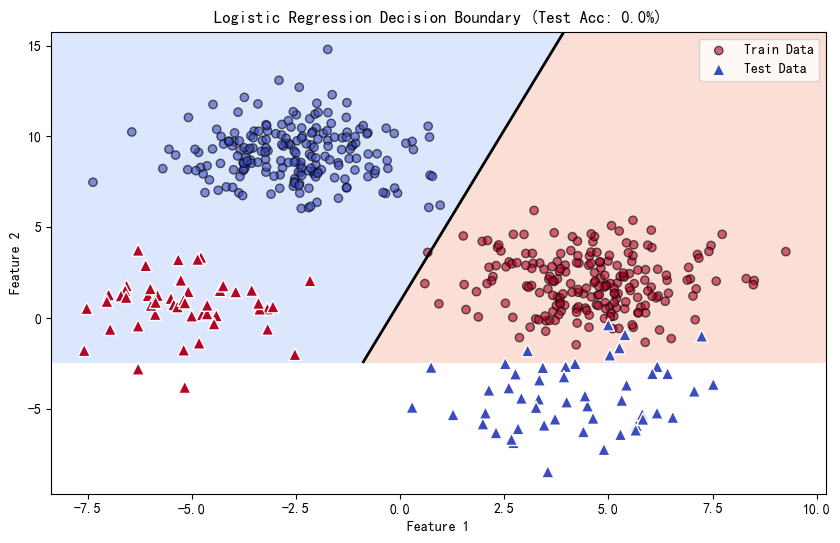

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# ================= 1. 生成数据 =================
# 生成两类线性可分的训练集数据：总共 400 个样本（每类 200 个），特征维度为 2
X_train, y_train = make_blobs(n_samples=400, n_features=2, centers=2, 
                              random_state=42, cluster_std=1.5)
# 生成测试集：新生成 100 个样本（每类 50 个）
X_test, y_test = make_blobs(n_samples=100, n_features=2, centers=2, 
                            random_state=123, cluster_std=1.5)

# 为了方便矩阵运算，将标签转为 (N, 1) 的列向量
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# ================= 2. 定义函数 =================
def sigmoid(z):
    # sigmoid 函数
    return 1.0 / (1.0 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred):
    # 二元交叉熵损失 (BCE Loss)
    epsilon = 1e-15 # 防止 log(0) 出现数值溢出
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    # L = -1/N * sum( y*log(y_hat) + (1-y)*log(1-y_hat) )
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# ================= 3. 梯度下降训练 =================
np.random.seed(42)
n_samples, n_features = X_train.shape

# 初始化参数 w 为 (2, 1) 的零矩阵，偏置 b 为 0
w = np.zeros((n_features, 1))
b = 0.0

learning_rate = 0.1
iterations = 1000
losses = []

print(f"=== 开始梯度下降训练 (LR={learning_rate}, Iterations={iterations}) ===")
for i in range(iterations):
    # [前向传播计算]
    z = np.dot(X_train, w) + b
    y_pred = sigmoid(z)
    
    # [计算并记录损失]
    loss = binary_cross_entropy(y_train, y_pred)
    losses.append(loss)
    
    # [反向传播：计算梯度]
    # BCE Loss 加上 Sigmoid 激活函数的导数极度简化为： y_pred - y_true
    dz = y_pred - y_train
    dw = np.dot(X_train.T, dz) / n_samples
    db = np.sum(dz) / n_samples
    
    # [参数更新]
    w -= learning_rate * dw
    b -= learning_rate * db
    
    # 每 100 次迭代打印一次损失
    if (i + 1) % 100 == 0 or i == 0:
        print(f"  Iteration {i + 1:4d}/{iterations} - Loss: {loss:.4f}")

# ================= 4. 测试集评估与绘制决策边界 =================
# 在新生成的测试集上预测
z_test = np.dot(X_test, w) + b
y_test_pred = sigmoid(z_test)
# 概率 >= 0.5 的归划为正类 (1)，否则为负类 (0)
y_test_pred_class = (y_test_pred >= 0.5).astype(int)

# 计算准确率
accuracy = np.mean(y_test_pred_class == y_test)
print("-" * 40)
print(f"✅ 模型训练结束！测试集（100个样本）准确率: {accuracy * 100:.2f}%\n")

# ---- 绘制决策边界和数据点可视化 ----
plt.figure(figsize=(10, 6))

# 获取作图边界 (Padding一下避免点贴边)
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# 预测网格中每个点的值，用于绘制彩色背景概率轮廓
Z_grid = sigmoid(np.dot(np.c_[xx.ravel(), yy.ravel()], w) + b)
Z_grid = Z_grid.reshape(xx.shape)

# 填充等高线轮廓 (背景颜色划分两类决策区域)
plt.contourf(xx, yy, Z_grid, levels=1, alpha=0.3, cmap=plt.cm.coolwarm)
# 也可以画一条中间清晰的边界线
plt.contour(xx, yy, Z_grid, levels=[0.5], colors='black', linewidths=2)

# 绘制训练集散点图
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train.flatten(), 
            edgecolors='k', marker='o', alpha=0.6, cmap=plt.cm.coolwarm, label='Train Data')

# 绘制测试集散点图 (用加粗并且带其他形状突出显示)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test.flatten(), 
            edgecolors='white', marker='^', s=80, cmap=plt.cm.coolwarm, label='Test Data')

plt.title(f'Logistic Regression Decision Boundary (Test Acc: {accuracy*100:.1f}%)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()